# Multiple Linear Regression
## lib와 데이터 로딩

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('datas_ml/50_Startups.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [4]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [5]:
df.describe(include='object')

,State
count,50
unique,3
top,New York
freq,17


In [7]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## X,y 데이터 분리

In [9]:
y=df['Profit']

In [10]:
X=df.loc[:, 'R&D Spend' : 'State']
X.head()

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida


## 데이터 전처리

In [12]:
X['State'].nunique()

3

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [15]:
ct = ColumnTransformer([('encoder', OneHotEncoder(), [3])],remainder='passthrough')

In [16]:
X = ct.fit_transform(X)

In [17]:
X[:5]

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.6534920e+05,
        1.3689780e+05, 4.7178410e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.6259770e+05,
        1.5137759e+05, 4.4389853e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.5344151e+05,
        1.0114555e+05, 4.0793454e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.4437241e+05,
        1.1867185e+05, 3.8319962e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.4210734e+05,
        9.1391770e+04, 3.6616842e+05]])

In [18]:
type(X)

numpy.ndarray

# 학습용과 테스트용으로 나눔
train_test_split(x, y, test_size=0.2, random_state=7)

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [22]:
X_train.shape, y_train.shape

((40, 6), (40,))

# 모델학습

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lr_model = LinearRegression()

In [25]:
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# 회귀선의 기울기
lr_model.coef_

array([-4.31767824e+02, -1.55681873e+03,  1.98858655e+03,  8.08286664e-01,
       -2.61729246e-02,  3.07501226e-02])

In [27]:
# 회귀선의 편차
lr_model.intercept_

np.float64(48803.932588414704)

# 모델 성능평가

In [ ]:
y_pred = y_hat
y_hat = (-4.31767824e+02*x1, -1.55681873e+03*x2,  1.98858655e+03*x3,  8.08286664e-01*x4,
       -2.61729246e-02*x5,  3.07501226e-02*x6) + 48803.932588414704

In [30]:
# 테스트
y_pred = lr_model.predict(X_test)

In [31]:
y_pred

array([126951.56211222, 148200.83566626, 113169.45069608,  69514.30155574,
        97132.05158376, 116589.98682741, 189485.65723754, 116210.87169485,
       133774.25331431,  73274.89058477])

In [32]:
# MSE
((y_test - y_pred)**2).mean()

np.float64(100911162.80590256)

In [33]:
# 오차결과 : RMSE
np.sqrt(((y_test - y_pred)**2).mean())

np.float64(10045.454833202057)

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [39]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2_s = r2_score(y_test, y_pred)

In [43]:
print(f"rmse={np.square(mse)}\nmae={mae}\nr2_s={r2_s}")

rmse=1.0183062778839372e+16
mae=7917.874510656649
r2_s=0.8998123419674642


## 실제값과 예측값 시각화

In [44]:
df_test = y_test.to_frame()

In [45]:
df_test

,Profit
13,134307.35
15,129917.04
22,110352.25
42,71498.49
30,99937.59
27,105008.31
1,191792.06
20,118474.03
10,146121.95
36,90708.19


In [46]:
df_test['y_pred'] = y_pred

In [47]:
df_test

,Profit,y_pred
13,134307.35,126951.562112
15,129917.04,148200.835666
22,110352.25,113169.450696
42,71498.49,69514.301556
30,99937.59,97132.051584
27,105008.31,116589.986827
1,191792.06,189485.657238
20,118474.03,116210.871695
10,146121.95,133774.253314
36,90708.19,73274.890585


In [48]:
df_test = df_test.reset_index(drop=True)

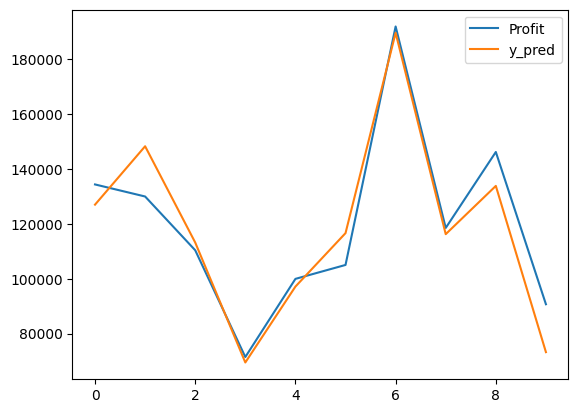

In [49]:
df_test.plot()
plt.show()

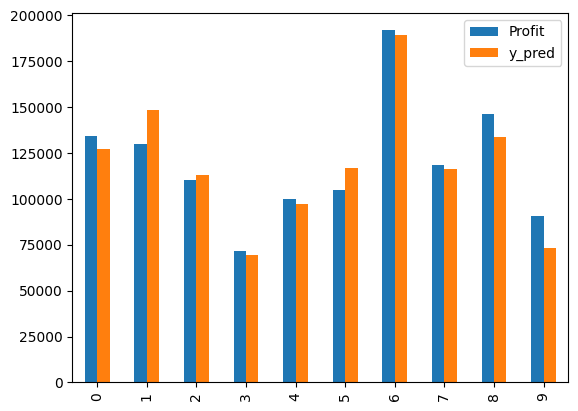

In [50]:
df_test.plot(kind='bar')
plt.show()

# 일반화 테스트
- 실제 값을 넣어보기

In [51]:
# 저희 회사는
# 운영비 15만달러, 마케팅비 40만달러, 연구개발비는 13만달러 쓰고 있습니다. 회사 위치는 플로리다에 있습니다.

In [91]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [92]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [102]:
ct.named_transformers_['encoder'].categories_

[array(['California', 'Florida', 'New York'], dtype=object)]

In [93]:
real_data = [0, 1, 0, 130000, 150000, 400000]
X_real = np.array(real_data)

In [98]:
X_real = X_real.reshape(1,-1)

In [99]:
X_real.shape

(1, 6)

In [101]:
y_real_pred=model_lr.predict(X_real)
y_real_pred

array([160698.49053132])

[실습]

- A회사는 운영비는 15만달라, 마케팅비는 40만달라, 연구개발비는 13만달라고 회사위치는 Florida에 있음  
- B회사는 운영비는 11만달라, 마케팅비는 60만달라, 연구개발비는 15만달라고 회사위치는 NewYork  
- 이 두 회사의 수익을 예측하세요.  
- predict 함수에 한번에 넣어서, 두 회사의 결과를 한번에 확인하세요.  

In [105]:
new_data = [[0, 1, 0, 130000, 150000, 400000], [0, 0, 1, 150000, 110000, 600000]]
X_new = np.array(new_data)
X_new

array([[     0,      1,      0, 130000, 150000, 400000],
       [     0,      0,      1, 150000, 110000, 600000]])

In [106]:
X_new = X_new.reshape(2, -1)

In [107]:
X_new.shape

(2, 6)

In [108]:
y_new_pred=model_lr.predict(X_new)
y_new_pred

array([160698.49053132, 187606.57059605])

# 모델 저장하기
- 예측을 잘 하면 서비스화를 위해 모델 저장하기
## 모델 저장하기

In [109]:
import joblib

In [111]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(lr_model, 'models/lr_model.pkl')

['models/lr_model.pkl']

## 저장된 모델 로딩하여 테스트

In [112]:
ai = joblib.load('models/lr_model.pkl')

In [113]:
ai.predict(new_data)

array([160698.49053132, 187606.57059605])